# Research Challenge

<div style="background-color: #f8d7da; border-left: 6px solid #ccc; margin: 20px; padding: 15px;">
    <strong>💡 Margaret Atwood:</strong> Every aspect of human technology has a dark side, including the bow and arrow.
</div>

## 🏅 Build your own model

It is time to go back to supervised machine learning problems.

You have been assigned one dataset from [MatBench](https://matbench.materialsproject.org) as introduced in the [Lecture slides](https://speakerdeck.com/aronwalsh/mlformaterials-challenge-25). You are free to choose and tune any machine-learning model, with any Python library, but it should be appropriate for the problem. For instance, [XGBoost](https://xgboost.readthedocs.io) could be a good starting starting point to build a regression model. You can refer back to earlier notebooks and repurpose code as needed.

You may reach the limits of computing processing power on Google Colab. Building a useful model with limited resources is a real-world skill. Using other free resources is allowed if you find an alternative service, as is running on your own computer. A model tracker such as [wandb](https://wandb.ai) could be helpful for advanced users. If you want to try a brute force approach, a library such as [Automatminer](https://hackingmaterials.lbl.gov/automatminer) may be of interest.

This notebook should be used for keeping a record of your model development, submission, and even your presentation. You are free to edit (add/remove/delete) or rearrange the cells as you see fit.

### Your details

In [60]:
import numpy as np

# Insert your values
Name = "Mark Zangwill" # Replace with your name
CID = 2198282 # Replace with your College ID (as a numeric value with no leading 0s)

# Set a random seed using the CID value
CID = int(CID)
np.random.seed(CID)

# Print the message
print("This is the work of " + Name + " [CID: " + str(CID) + "]\n")

# Define the available groups
groups = ['A', 'B', 'C', 'D', 'E']

# Select a group based on the seeded random state
challenge_group = np.random.choice(groups)

# Print the challenge code
print("Your challenge code is " + challenge_group)

This is the work of Mark Zangwill [CID: 2198282]

Your challenge code is C


## Problem statement
You have been assigned one dataset from the [list](https://matbench.materialsproject.org/Benchmark%20Info/matbench_v0.1/) on [MatBench](https://matbench.materialsproject.org). You should state what problem you are trying to solve and comment on the best-performing model in the benchmark.

In [61]:
# Spare cell




## Data preparation

Check the data distribution and apply appropriate pre-processing steps as required.

In [62]:
# Installation of libraries
!pip install matminer # Datasets and featurisation

In [63]:
# Get dataset info from matminer
from matminer.datasets import get_all_dataset_info
from matminer.datasets import load_dataset

# Detailed on https://hackingmaterials.lbl.gov/matminer/dataset_summary.html
# Uncomment the info line for your assigned challenge code

  # A
#info = get_all_dataset_info("matbench_dielectric")

  # B
#info = get_all_dataset_info("matbench_expt_gap")

  # C
info = get_all_dataset_info("matbench_expt_is_metal")

  # D
#info = get_all_dataset_info("matbench_glass")

  # E
#info = get_all_dataset_info("matbench_steels")

# Check the dataset information
print(info)

Dataset: matbench_expt_is_metal
Description: Matbench v0.1 test dataset for classifying metallicity from composition alone. Retrieved from Zhuo et al. supplementary information. Deduplicated according to composition, ensuring no conflicting reports were entered for any compositions (i.e., no reported compositions were both metal and nonmetal). For benchmarking w/ nested cross validation, the order of the dataset must be identical to the retrieved data; refer to the Automatminer/Matbench publication for more details.
Columns:
	composition: Chemical formula.
	is_metal: Target variable. 1 if is a metal, 0 if nonmetal.
Num Entries: 4921
Reference: Y. Zhuo, A. Masouri Tehrani, J. Brgoch (2018) Predicting the Band Gaps of Inorganic Solids by Machine Learning J. Phys. Chem. Lett. 2018, 9, 7, 1668-1673 
 https//:doi.org/10.1021/acs.jpclett.8b00124.
Bibtex citations: ["@Article{Dunn2020,\nauthor={Dunn, Alexander\nand Wang, Qi\nand Ganose, Alex\nand Dopp, Daniel\nand Jain, Anubhav},\ntitle={Benc

In [64]:
# Load your dataset into a pandas DataFrame
df = load_dataset("matbench_expt_is_metal")

print(df)

            composition  is_metal
0              Ag(AuS)2      True
1            Ag(W3Br7)2      True
2      Ag0.5Ge1Pb1.75S4     False
3     Ag0.5Ge1Pb1.75Se4     False
4                Ag2BBr      True
...                 ...       ...
4916             ZrTaN3     False
4917               ZrTe      True
4918             ZrTi2O      True
4919             ZrTiF6      True
4920               ZrW2      True

[4921 rows x 2 columns]


In [65]:
df.describe()

,composition,is_metal
count,4921,4921
unique,4921,2
top,ZrW2,False
freq,1,2470


Where middle column is the "composition" column, with all 4921 being unique. The last column beign the output, unique being two since outputs are either true or false, depending on whenther metal or non.

Choose relevant features, which may be based on composition or structure, depending on your problem. [matminer](https://hackingmaterials.lbl.gov/matminer/) is a good place to start.

###Materials Featurization

In [66]:
#download ElementEmbedings
!pip install elementembeddings

Method for featurizing dataframe with chosen embeding scheme (e.g. magpie) and stats (e.g. minpool)

In [67]:
# Featurise all chemical compositions
from elementembeddings.composition import composition_featuriser

def featurise(dataframe, embedding, stats):

  if stats  == "all":
    stats = ["mean"] #leaving out: "variance", "minpool","maxpool", "range","sum", "geometric_mean", "harmonic_mean", to make faster
  else:
    stats = stats

  featurised_df = composition_featuriser(dataframe["composition"], embedding=embedding, stats=stats)

  # Convert "is_metal" column to integer labels (0, 1)
  dataframe['is_metal'] = dataframe['is_metal'].astype(int)
  featurised_df['is_metal'] = dataframe['is_metal']

  # Define feature matrices and target variable
  cols_to_drop = ['is_metal', 'formula']

  X = featurised_df.drop(columns=cols_to_drop, errors='ignore').values # leaving only featurized composition left
  y = dataframe['is_metal'].values  # Target variable

  return featurised_df, X, y

In [68]:
featurised_df, X,  y = featurise(df, "magpie", "all")

print(featurised_df.iloc[:2, :4])

Featurising compositions...


100%|██████████| 4921/4921 [00:25<00:00, 189.29it/s]


Computing feature vectors...


100%|██████████| 4921/4921 [00:00<00:00, 102009.38it/s]


      formula  mean_Number  mean_MendeleevNumber  mean_AtomicWeight
0    Ag(AuS)2    47.400000                  74.6         113.186268
1  Ag(W3Br7)2    46.714286                  81.0         110.931629


In [69]:
print(featurised_df.shape)

(4921, 24)


In [70]:
print(X.shape)

(4921, 22)


pick the best stats to use. e.g. mean or variance or ...

embedding scheme could also be tested...Use decsion tree since faster

In [71]:
from sklearn.feature_selection import RFECV
from sklearn.model_selection import StratifiedKFold
from sklearn.tree import DecisionTreeClassifier
from sklearn.pipeline import Pipeline

# Define the model

models = (DecisionTreeClassifier(),) #, RandomForestClassifier()) #establish models which will be used

for model in models:

  min_features_to_select = 1  # Minimum number of features to consider
  cv = StratifiedKFold(2) # using lower fold numbers to run quicker

  rfecv = RFECV(  #apply recursive feature elimination with cross-validation
      estimator=model,
      step=1,
      cv=cv,
      scoring= "roc_auc", # Corrected from 'roc_auc_score' to 'roc_auc'
      min_features_to_select=min_features_to_select,
      n_jobs=2,
  )
  rfecv.fit(X, y)

  print(f"Optimal number of features for {model.__class__.__name__} : {rfecv.n_features_}")

Optimal number of features for DecisionTreeClassifier : 8


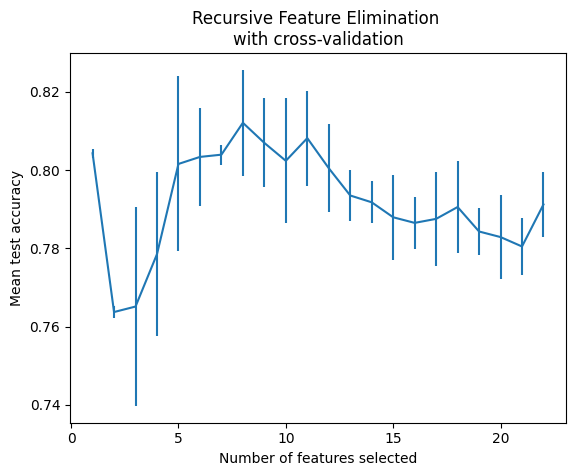

In [72]:
import matplotlib.pyplot as plt
import pandas as pd

data = {
    key: value
    for key, value in rfecv.cv_results_.items()
    if key in ["n_features", "mean_test_score", "std_test_score"]
}
cv_results = pd.DataFrame(data)
plt.figure()
plt.xlabel("Number of features selected")
plt.ylabel("Mean test accuracy")
plt.errorbar(
    x=cv_results["n_features"],
    y=cv_results["mean_test_score"],
    yerr=cv_results["std_test_score"],
)
plt.title("Recursive Feature Elimination \nwith cross-validation")
plt.show()

## Model selection, testing and training

Define your model and justify your choice based on the problem and available data. You can look back at earlier notebooks and investigate other examples online including in [scikit-learn](https://scikit-learn.org).

Train, validate and test your model. Make sure to do proper data splits and to consider the hyperparamaters of your model.

<details>
<summary>Note on the ROC-AUC classification metric</summary>
There is one metric we didn't cover but is used in Matbench. In binary classification models, the ROC-AUC (Receiver Operating Characteristic - Area Under the Curve) score can be used to evaluate performance. It quantifies the ability of the model to distinguish between positive and negative instances across different decision thresholds. A higher ROC-AUC score (ranging from 0.5 to 1) indicates better performance, with 1 representing a perfect classifier and 0.5 indicating performance no better than random chance. There is a more detailed discussion here: https://developers.google.com/machine-learning/crash-course/classification/roc-and-auc.

The metric can be calculated using the `roc_auc_score` function from the `sklearn.metrics` module, e.g.

```python
from sklearn.metrics import roc_auc_score

# Assuming you have true labels (y_true) and predicted probabilities (y_pred_prob)
y_true = [...]  
y_pred_prob = [...]  

# Calculate ROC-AUC
roc_auc = roc_auc_score(y_true, y_pred_prob)

# Display the result
print(f'ROC-AUC Score: {roc_auc:.4f}')
```
</details>

Can see that fewer than the original 132 features are produce better results and will be less computationaly demanding when doing full training and tuning of hyperparameters on large cross validation

To conduct hyperparameter optimization, nested crossed validation is requred as to not leak data, giving optimisitic results. This involves having two loops; an inner and outer. The inner is where featurization is done as well as hyperparameter optimization. the outer does test.

Train, validate and test your model. Make sure to do proper data splits and to consider the hyperparamaters of your model.

<details>
<summary>Note on the ROC-AUC classification metric</summary>
There is one metric we didn't cover but is used in Matbench. In binary classification models, the ROC-AUC (Receiver Operating Characteristic - Area Under the Curve) score can be used to evaluate performance. It quantifies the ability of the model to distinguish between positive and negative instances across different decision thresholds. A higher ROC-AUC score (ranging from 0.5 to 1) indicates better performance, with 1 representing a perfect classifier and 0.5 indicating performance no better than random chance. There is a more detailed discussion here: https://developers.google.com/machine-learning/crash-course/classification/roc-and-auc.

The metric can be calculated using the `roc_auc_score` function from the `sklearn.metrics` module, e.g.

```python
from sklearn.metrics import roc_auc_score

# Assuming you have true labels (y_true) and predicted probabilities (y_pred_prob)
y_true = [...]  
y_pred_prob = [...]  

# Calculate ROC-AUC
roc_auc = roc_auc_score(y_true, y_pred_prob)

# Display the result
print(f'ROC-AUC Score: {roc_auc:.4f}')
```
</details>

In [73]:
import numpy as np
from matplotlib import pyplot as plt

from sklearn.model_selection import GridSearchCV, StratifiedKFold, cross_val_score #stratifieskfold as matbench specifies
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier  #ensemble models will generaly perfrom better
from sklearn.feature_selection import RFECV
from sklearn.pipeline import Pipeline

def nestedCrossValidation_gridSearch(model, X, y, folds=2):

  """Perform nested cross-validation on model specified using GridSearchCV.

  Args:
    model: The class of the model to be used (e.g., RandomForestClassifier).
    X: Feature matrix.
    y: Target variable.
    folds: Number of folds for RFECV's internal cross-validation (default: 2).

  Returns:
    The mean ROC-AUC score from the outer cross-validation loop."""

  if model == DecisionTreeClassifier:
    model = DecisionTreeClassifier()
    grid = {
        "rfecv__min_features_to_select": [X.shape[1], 10,5], # where setting to X.shape[1] means retaining all features
        "rfecv__step": [1],
        "model__max_depth": [None, 5, 10, 20],
        "model__min_samples_leaf": [1, 5, 10, 20],
        "model__criterion": ['gini', 'entropy']
           }
  elif model == RandomForestClassifier:
    model = RandomForestClassifier()

    grid = {
        "rfecv__min_features_to_select": [X.shape[1], 10,5],
        "rfecv_step": [1],
        "model__n_estimators": [100, 200, 300],
        "model__max_depth": [None, 5, 10, 20],
        "model__min_samples_leaf": [1, 5, 10, 20],
        "model__max_features": ["sqrt", "log2"],
        "model__criterion": ["gini", "entropy"]
          }
  elif model == GradientBoostingClassifier:
    model = GradientBoostingClassifier()

    grid = {
        "rfecv__min_features_to_select": [X.shape[1], 10,5],
        "rfecv_step": [1],
        "model__n_estimators": [100, 200, 300],
        "model__learing_rate": [0.01, 0.1, 1],
        "model__max_depth": [3, 5, 10],
        "model__min_samples_split": [2, 5, 10],
        "model__min_samples_leaf": [1, 5, 10],
        "model__max_features": ["sqrt", "log2"],
        "model__subsample": [0.8, 0.9, 1.0]
          }

  else:
    print("model not recognised")
    return None

  # Define the pipeline for RFECV and DecisionTreeClassifier
  pipe = Pipeline([
      ("rfecv", RFECV(estimator=model, cv=StratifiedKFold(n_splits=folds), scoring='roc_auc', n_jobs=2)), # cv here will be overridden by inner_cv
      ("model", model)
  ])

  # Choose cross-validation techniques for the inner and outer loops,
  # independently of the dataset.
  inner_cv = StratifiedKFold(n_splits=folds, shuffle=True, random_state=18012019) #shuffle set to True with specific state as matbench specifies
  outer_cv = StratifiedKFold(n_splits=folds, shuffle=True, random_state=18012019) #stratifiedKfold used since it maintains same propoortion of target classes (metal/non-metal) within each fold

  # Nested CV with hyperparameter optimization and feature selection optimization
  gridSearchModel = GridSearchCV(estimator=pipe, param_grid=grid, cv=inner_cv, scoring='roc_auc', n_jobs=2)
  gridSearchModel.fit(X, y)
  nested_score = cross_val_score(gridSearchModel.best_estimator_, X=X, y=y, cv=outer_cv, scoring='roc_auc') #number scores given based off number outer folds
  mean_score = nested_score.mean()

  return mean_score

In [74]:
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import randint, uniform

def nestedCrossValidation_randomSearch(model, X, y, n_iter, folds=2):

  """Perform nested cross-validation on model specified using RandomizedSearchCV.

  Args:
    model: The class of the model to be used (e.g., RandomForestClassifier).
    X: Feature matrix.
    y: Target variable.
    n_inter: Number of parameter settings that are sampled. Passed to RandomizedSearchCV.
    folds: Number of folds for RFECV's internal cross-validation (default: 2).

  Returns:
    The mean ROC-AUC score from the outer cross-validation loop."""

  if model == DecisionTreeClassifier:
    model = DecisionTreeClassifier()
    parameters = {
      "rfecv__min_features_to_select": [X.shape[1], 10, 5],
        "rfecv__step": [1],
        "model__max_depth": [None] + list(randint(1, 21).rvs(20)), # Adding None and random integers
        "model__min_samples_leaf": randint(1, 21),
        "model__criterion": ['gini', 'entropy']
      }

  elif model == RandomForestClassifier:
    model = RandomForestClassifier()
    parameters = {

    "rfecv__min_features_to_select": [X.shape[1], 10, 5],
        "rfecv__step": [1],
        "model__n_estimators": randint(50, 301),
        "model__max_depth": [None] + list(randint(1, 21).rvs(20)),
        "model__min_samples_leaf": randint(1, 21),
        "model__max_features": ['sqrt', 'log2', 1.0],
        "model__criterion": ['gini', 'entropy']
    }

  elif model == GradientBoostingClassifier:
    model = GradientBoostingClassifier()
    parameters = {
    "rfecv__min_features_to_select": [X.shape[1], 10, 5],
        "rfecv__step": [1],
        "model__n_estimators": randint(50, 301),
        "model__learning_rate": uniform(0.01, 0.2),
        "model__max_depth": randint(3, 11),
        "model__min_samples_split": randint(2, 11),
        "model__min_samples_leaf": randint(1, 11),
        "model__max_features": ['sqrt', 'log2', None],
        "model__subsample": uniform(0.6, 0.4) # uniform(loc, scale) where scale is (high - low)
    }

  else:
    print("model not recognised")
    return None

  # Define the pipeline for RFECV and model classifier
  pipe = Pipeline([
      ('rfecv', RFECV(estimator=model, cv=StratifiedKFold(n_splits=folds), scoring='roc_auc', n_jobs=2)), # cv here will be overridden by inner_cv
      ('model', model)
  ])

  # Choose cross-validation techniques for the inner and outer loops,
  # independently of the dataset.
  inner_cv = StratifiedKFold(n_splits=folds, shuffle=True, random_state=18012019) #shuffle set to True with specific state as matbench specifies
  outer_cv = StratifiedKFold(n_splits=folds, shuffle=True, random_state=18012019) #stratifiedKfold used since it maintains same propoortion of target classes (metal/non-metal) within each fold

  # Nested CV with hyperparameter optimization and feature selection optimization
  randomSearchModel = RandomizedSearchCV(estimator=pipe, param_distributions=parameters, n_iter=n_iter, cv=inner_cv, scoring='roc_auc', n_jobs=2)
  randomSearchModel.fit(X, y)
  nested_score = cross_val_score(randomSearchModel.best_estimator_, X=X, y=y, cv=outer_cv, scoring='roc_auc') #number scores given based off number outer folds
  mean_score = nested_score.mean()

  return mean_score


## Model analysis and discussion

How well does your final model perform? Think of metrics and plots that are useful to dig a little deeper.

Compare against the best-performing model on the [MatBench](https://matbench.materialsproject.org) leaderboard.  With limited resources, don't expect to match this performance, but you should do better than a baseline model.

Compare gridsearch method with random search method

In [75]:
import time

def gridSearchPerformance(model, X, y, folds = 5):

  start_time = time.time()

  mean_score = nestedCrossValidation_gridSearch(model, X, y, folds)

  end_time = time.time()

  return mean_score, end_time - start_time

In [76]:
model = DecisionTreeClassifier

featurised_df, X, y = featurise(df, "magpie", "all")
mean_grid_score, grid_time = gridSearchPerformance(model, X, y, folds = 2)
print(mean_grid_score)
print(grid_time)

Featurising compositions...


100%|██████████| 4921/4921 [00:19<00:00, 249.66it/s]


Computing feature vectors...


100%|██████████| 4921/4921 [00:00<00:00, 187724.95it/s]


0.9148099135223103
157.25426292419434


In [80]:
import time

def randomSearchPerformance(model, X, y, start_n_iter = 3, end_n_iter = 9, step = 3, folds = 5):

  n_iter = []
  times = []
  mean_scores = []

  for i in range(start_n_iter,end_n_iter + 1, step):
    start_time = time.time()
    mean_score = nestedCrossValidation_randomSearch(model, X, y, i, folds)
    end_time = time.time()
    n_iter.append(i)
    times.append(end_time - start_time)
    mean_scores.append(mean_score)

  return n_iter, times, mean_scores

Plot how the perfomance changes with number iterations allowed to tune hyperparameters

In [ ]:
models = (DecisionTreeClassifier, RandomForestClassifier, GradientBoostingClassifier)

results = {}

for model in models:
  featurised_df, X, y = featurise(df, "magpie", "all")
  n_iter, times, mean_scores = randomSearchPerformance(model, X, y, start_n_iter=3, end_n_iter=9, step = 3, folds = 2)
  print(times)
  results[model.__name__] = (n_iter, times, mean_scores)

Featurising compositions...


100%|██████████| 4921/4921 [00:14<00:00, 333.52it/s]


Computing feature vectors...


100%|██████████| 4921/4921 [00:00<00:00, 62198.41it/s]


In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(7, 5))

markers = ['o', 's', '^']

for (model_name, (n_iter, times, mean_scores)), marker in zip(results.items(), markers):
  plt.plot(n_iter, mean_scores, marker=marker, linewidth = 2, label = model_name)

plt.xlabel("Number of Random Search Iterations")
plt.ylabel("Mean ROC-AUC Score")
plt.title("Model Performance vs Number of Random Search Iterations")

plt.grid(axis = "y", linestyle = "--", alpha = 0.4)
plt.legend()
plt.tight_layout()

plt.show

Because randomsearch tries n_iter number of parameter combinations, some paramaeter combinations take shorter amount of time than others so, atleast when n_iter is small, n_iter = 1 can take longer that n_iter = 5. For example one may take all features to be hyperoptimised whilst the other may only take fewer.

Because random search considers values maybe not considered in grid search, it can find a more optimised configuration. since grid search can only optimise for the grid its been given, which are a descrete number values. whilst randomsearch uses contimuos functions which are samples

larger values of n_iter should be used since need to sample a large space. However for fast model, restriced to using small n_iter

after only 3 minutes , the model was able to find better than grid search, thus this model (n_iter) should be tried out against using pca or different features e.g mean or variance of the magpie dataset

In [86]:
#change the stats used in the embedding scheme

stats = ["mean", "variance", "minpool","maxpool", "range","sum", "geometric_mean", "harmonic_mean"]
mean_scores = []
for stat in stats:
  featurised_df, X, y = featurise(df, "magpie", stat)
  model = DecisionTreeClassifier # test on DecisionTreeClassifier since quicker
  n_iter, times, mean_score = randomSearchPerformance(model, X, y, start_n_iter=10, end_n_iter=10, folds = 2) # use 10 iterations to give good hyperparamter choice
  mean_scores.append(mean_score)

Featurising compositions...


100%|██████████| 4921/4921 [00:13<00:00, 351.64it/s]


Computing feature vectors...


100%|██████████| 4921/4921 [00:00<00:00, 146229.66it/s]


Featurising compositions...


...

  0%|          | 0/4921 [00:00<?, ?it/s]/usr/local/lib/python3.12/dist-packages/elementembeddings/composition.py:195: RuntimeWarning: divide by zero encountered in log
  return np.exp(np.dot(self.norm_stoich_vector, np.log(self.el_matrix)))
100%|██████████| 4921/4921 [00:00<00:00, 87989.64it/s]


Featurising compositions...


100%|██████████| 4921/4921 [00:20<00:00, 245.14it/s]


Computing feature vectors...


  0%|          | 0/4921 [00:00<?, ?it/s]/usr/local/lib/python3.12/dist-packages/elementembeddings/composition.py:200: RuntimeWarning: divide by zero encountered in reciprocal
  np.dot(self.norm_stoich_vector, np.reciprocal(self.el_matrix)),
100%|██████████| 4921/4921 [00:00<00:00, 66608.70it/s]


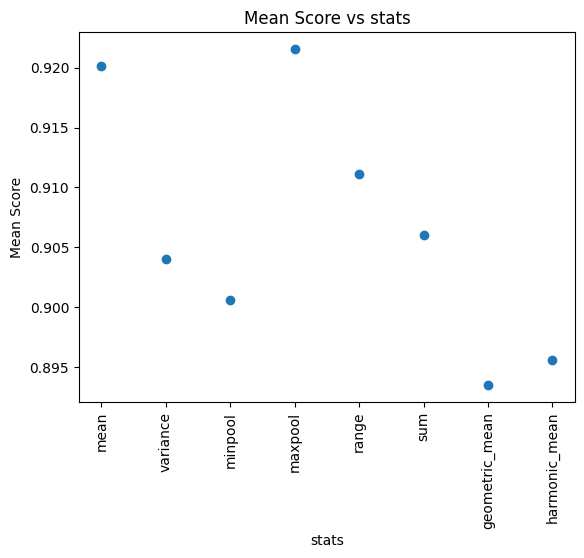

In [90]:
plt.scatter(stats, mean_scores)
#set the x axis with every stat written sideways
plt.xticks(stats, rotation=90)
plt.xlabel('stats')
plt.ylabel('Mean Score')
plt.title('Mean Score vs stats')
plt.show()

without hyperperameter optimisation, and only feature optimisation, a decision treeclasifier doesnt require all features. However when hyperperameter tuning. Retaing all features provides best score.

Applying this type of cross validation and grid hyperameter tuning on ensemble methods would take too long.
Use Out of bag for

## Large Language Model (LLM) usage declaration

Acknowledge use of a generative model during your assignment. Points to consider:

* State which LLM (e.g. GPT-4, Gemini, Co-Pilot)

* Specify tasks (e.g. summarising research or code snippets)

* Were any limitations/biases noted?

* How did you ensure ethical use?

The built in Gemini 2.5 Flash was used duirng this project. Most of the time to explain errors occuring. Sometimes used as line autofill for simple tasks, i.e. clicking tab to autofill half written lines.

The suggestions for errors corrections (in English) were quite accurate however autocorrect (writing in python) doesn't work as well when integrating with other bits of code.

Ensured etihcal use by only using LLM to aid with syntax and errors, whilst the structure and models to test were entirely mine.